# MidiPatchy data feeder — iteration visualization

Loads the `MidiPatchy` dataset via `configs/midi-patchy-data.yaml` and visualizes what
the feeder yields each iteration: patch-sequence shapes, the per-item attention /
supervision masks, the token-id heatmap of a patch window, and the MidiText events a
cropped window decodes back to.

Config: `configs/midi-patchy-data.yaml` · Data: `~/data/midi/patches/midi-test202606.midi-notagen.pt`

Packed from `~/data/midi/test202606/txt` with `tools/midi/preprocessMidi.py`.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import torch
import numpy as np
import matplotlib.pyplot as plt

from starry.utils.config import Configuration
from starry.utils.dataset_factory import loadDataset
from starry.midi.tokenizer import MidiTokenizer

DATA_DIR = str(Path.home() / 'data' / 'midi' / 'patches')
CONFIG = str(REPO_ROOT / 'configs' / 'midi-patchy-data.yaml')
print('repo:    ', REPO_ROOT)
print('data dir:', DATA_DIR)
print('config:  ', CONFIG)

repo:     /home/camus/work/deep-starry
data dir: /home/camus/data/midi/patches
config:   /home/camus/work/deep-starry/configs/midi-patchy-data.yaml


## 1. Load the dataset through the config

`loadDataset` reads the `imports:` field (`starry.midi.data.patchy`) to register
`MidiPatchy`, joins `data_dir` with `data.root`, and returns train/val DataLoaders. The
train split shuffles and random-crops each song to `patch_length`; val takes the head.

In [2]:
config = Configuration.createOrLoad(CONFIG, volatile=True)
config['data.batch_size'] = 4
config['data.args.patch_length'] = 512   # smaller window for clearer visuals

train, val = loadDataset(config, data_dir=DATA_DIR, device='cpu')

tk = MidiTokenizer(patch_size=config['data.args.patch_size'])
print('dataset type :', config['data.type'])
print('patch_size   :', config['data.args.patch_size'], '| patch_length:', config['data.args.patch_length'])
print('vocab_size   :', tk.vocab_size, '(pad=%d bos=%d eos=%d)' % (tk.pad_id, tk.bos_id, tk.eos_id))
print('train items  :', len(train.dataset), '| val items:', len(val.dataset))

dataset type : MidiPatchy
patch_size   : 16 | patch_length: 512
vocab_size   : 37 (pad=0 bos=1 eos=2)
train items  : 107 | val items: 11


## 1b. Raw sample-length distribution (full songs, before cropping)

The packer stores each song's **full** event sequence (no `patch_length` cap — cropping
happens at load time). Reading the artifact directly shows the true per-song patch-count
distribution; the `patch_length` line marks where the feeder will crop.

songs           : 118
patch-seq length: min=526  max=71283  mean=8931  median=5201
longer than patch_length(512): 118 / 118 (100%)


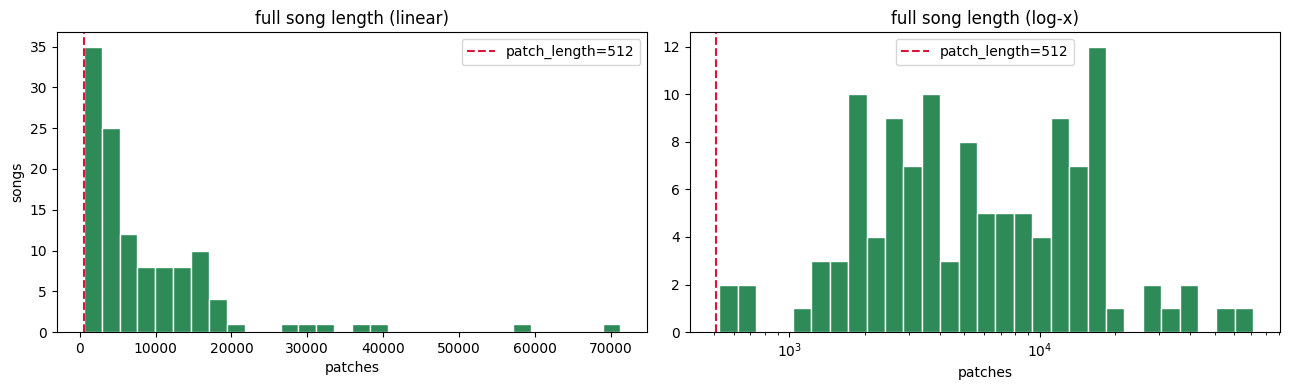

In [3]:
import os

# Read the artifact directly to get the FULL (uncropped) per-song patch counts. Works for
# both single-file (items) and sharded (index -> shard files) layouts.
root = os.path.join(DATA_DIR, config['data.root'])
art = torch.load(root, map_location='cpu')

if art.get('format', '').endswith('-sharded'):
    raw_lengths = []
    base = os.path.dirname(root)
    for sh in art['shards']:
        items = torch.load(os.path.join(base, sh['file']), map_location='cpu')['items']
        raw_lengths += [it['patches'].shape[0] for it in items]
else:
    raw_lengths = [it['patches'].shape[0] for it in art['items']]

raw_lengths = np.array(raw_lengths)
pl = config['data.args.patch_length']
print('songs           :', len(raw_lengths))
print('patch-seq length: min=%d  max=%d  mean=%d  median=%d' %
      (raw_lengths.min(), raw_lengths.max(), int(raw_lengths.mean()), int(np.median(raw_lengths))))
print('longer than patch_length(%d): %d / %d (%.0f%%)' %
      (pl, (raw_lengths > pl).sum(), len(raw_lengths), 100 * (raw_lengths > pl).mean()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(raw_lengths, bins=30, color='seagreen', edgecolor='white')
axes[0].axvline(pl, color='crimson', ls='--', lw=1.5, label='patch_length=%d' % pl)
axes[0].set_title('full song length (linear)'); axes[0].set_xlabel('patches'); axes[0].set_ylabel('songs'); axes[0].legend()
axes[1].hist(raw_lengths, bins=np.logspace(np.log10(raw_lengths.min()), np.log10(raw_lengths.max()), 30), color='seagreen', edgecolor='white')
axes[1].axvline(pl, color='crimson', ls='--', lw=1.5, label='patch_length=%d' % pl)
axes[1].set_xscale('log'); axes[1].set_title('full song length (log-x)'); axes[1].set_xlabel('patches'); axes[1].legend()
plt.tight_layout(); plt.show()

## 2. One batch: shapes & masks

`collateBatch` pads variable-length crops to the batch max and emits three aligned
tensors: `input_patches [B,T,patch_size]`, `input_masks [B,T]` (1 = real patch), and
`input_targets [B,T]` (1 = supervised prediction target; the leading `<bos>` is masked).

input_patches: (4, 512, 16) torch.int64
input_masks  : (4, 512) torch.int64
input_targets: (4, 512) torch.int64
max token id : 35 / vocab 37

item 0: real patches=512, target patches=511
item 1: real patches=512, target patches=511
item 2: real patches=512, target patches=511
item 3: real patches=512, target patches=511


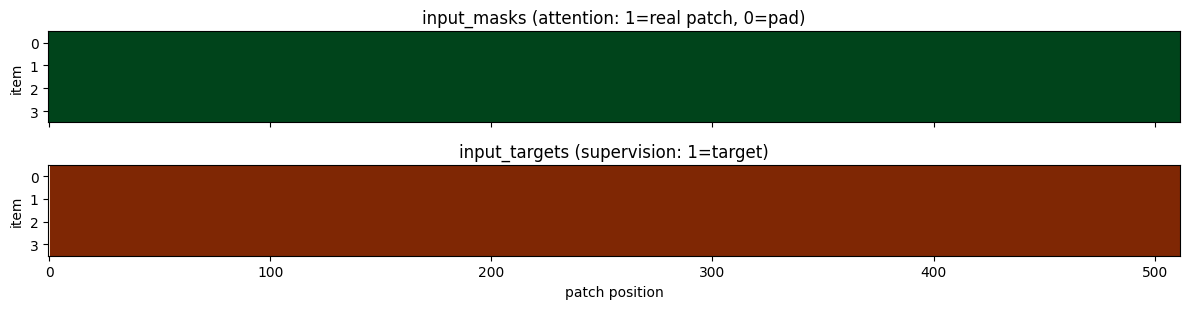

In [4]:
batch = next(iter(train))
P, M, Tg = batch['input_patches'], batch['input_masks'], batch['input_targets']

print('input_patches:', tuple(P.shape), P.dtype)
print('input_masks  :', tuple(M.shape), M.dtype)
print('input_targets:', tuple(Tg.shape), Tg.dtype)
print('max token id :', int(P.max()), '/ vocab', tk.vocab_size)
print()
for i in range(P.shape[0]):
    print('item %d: real patches=%d, target patches=%d' % (i, int(M[i].sum()), int(Tg[i].sum())))

# masks as an image: rows = batch items, cols = patch positions
fig, axes = plt.subplots(2, 1, figsize=(12, 3.2), sharex=True)
axes[0].imshow(M.numpy(), aspect='auto', cmap='Greens', vmin=0, vmax=1, interpolation='nearest')
axes[0].set_ylabel('item'); axes[0].set_title('input_masks (attention: 1=real patch, 0=pad)')
axes[1].imshow(Tg.numpy(), aspect='auto', cmap='Oranges', vmin=0, vmax=1, interpolation='nearest')
axes[1].set_ylabel('item'); axes[1].set_xlabel('patch position'); axes[1].set_title('input_targets (supervision: 1=target)')
for ax in axes:
    ax.set_yticks(range(P.shape[0]))
plt.tight_layout(); plt.show()

## 3. Token-id heatmap of one patch window

Each row is one event-patch, each column a token slot (0..patch_size-1). Column 0 is the
event-name token; the rest are hex/space content, right-padded with `<pad>`. The leading
row is the `<bos>` boundary patch.

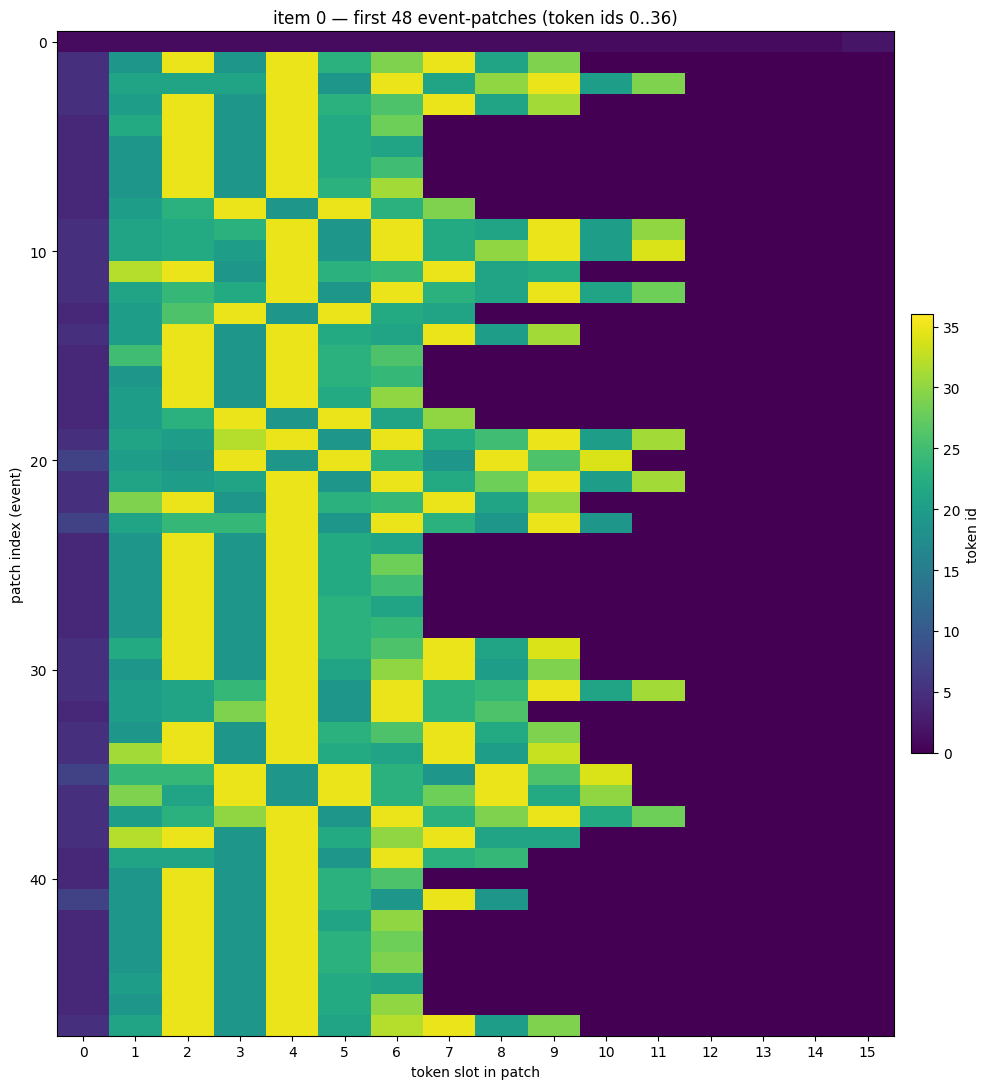

event-name column for first 48 patches:
['<bos>', 'note_on', 'note_on', 'note_on', 'note_off', 'note_off', 'note_off', 'note_off', 'note_off', 'note_on', 'note_on', 'note_on', 'note_on', 'note_off', 'note_on', 'note_off', 'note_off', 'note_off', 'note_off', 'note_on', 'control_change', 'note_on', 'note_on', 'control_change', 'note_off', 'note_off', 'note_off', 'note_off', 'note_off', 'note_on', 'note_on', 'note_on', 'note_off', 'note_on', 'note_on', 'control_change', 'note_on', 'note_on', 'note_on', 'note_off', 'note_off', 'control_change', 'note_off', 'note_off', 'note_off', 'note_off', 'note_off', 'note_on']


In [5]:
item = P[0]                       # [T, patch_size]
n_show = 48                       # first N event-patches
window = item[:n_show].numpy()

fig, ax = plt.subplots(figsize=(10, 11))
im = ax.imshow(window, aspect='auto', cmap='viridis', vmin=0, vmax=tk.vocab_size - 1, interpolation='nearest')
ax.set_xlabel('token slot in patch'); ax.set_ylabel('patch index (event)')
ax.set_title('item 0 — first %d event-patches (token ids 0..%d)' % (n_show, tk.vocab_size - 1))
ax.set_xticks(range(0, item.shape[1]))
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='token id')
plt.tight_layout(); plt.show()

# event-name (column 0) of those patches, decoded back to token strings
col0 = [tk.token_by_id.get(int(t), '?') for t in item[:n_show, 0]]
print('event-name column for first %d patches:' % n_show)
print(col0)

## 4. Decode a cropped window back to MidiText

Round-trip check: the patches the feeder yields decode back to readable MidiText event
lines (`decode_patches` strips boundary/pad). This confirms the crop preserves valid
events and the `<bos>` marker rides at the front of every window.

In [6]:
text = tk.decode_patches(P[0].tolist())
lines = text.split('\n')
print('item 0 window decoded to %d MidiText event lines' % len(lines))
print('first patch is <bos>:', int(P[0, 0, 0]) == tk.bos_id)
print('\n--- first 15 decoded events ---')
for l in lines[:15]:
    print('  ', l)

item 0 window decoded to 511 MidiText event lines
first patch is <bos>: True

--- first 15 decoded events ---
   note_on 0 0 4a 2a
   note_on 222 0 2b 1a
   note_on 1 0 47 2c
   note_off 3 0 39
   note_off 0 0 32
   note_off 0 0 36
   note_off 0 0 4c
   note_off 14 0 4a
   note_on 234 0 32 1b
   note_on 231 0 3b 1f
   note_on d 0 45 23
   note_on 253 0 42 29
   note_off 17 0 32
   note_on 1 0 32 1c
   note_off 6 0 47


## 5. Iterate several batches: window-length & event-type distribution

Drains a few train batches to show the feeder in motion — random crops give varying
real-patch counts per item, and the event-name mix reflects what MIDI songs contain
(mostly `note_on`/`note_off`/`control_change`).

drained 6 batches, 24 items
real-patch count per item: min=512 max=512 mean=512


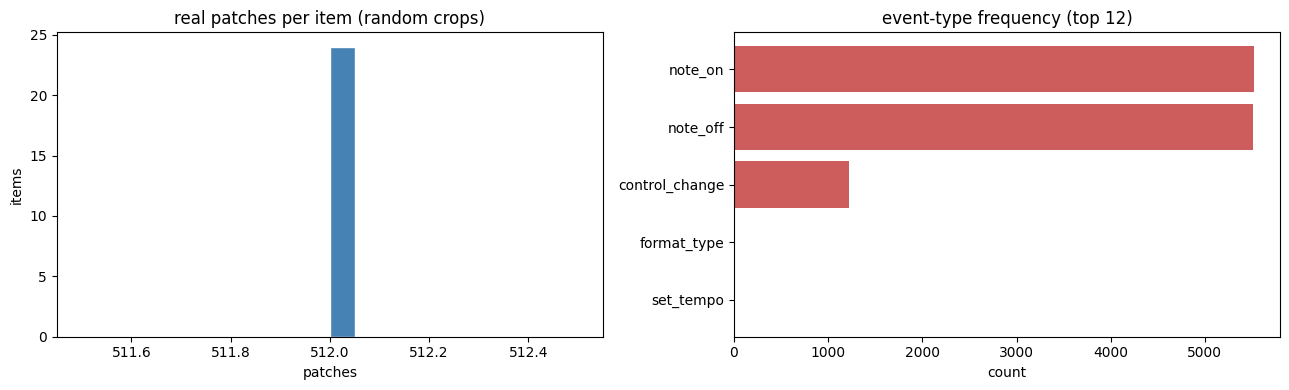

In [7]:
from collections import Counter

real_counts = []
event_counter = Counter()
n_batches = 6
it = iter(train)
for b in range(n_batches):
    bt = next(it)
    pp, mm = bt['input_patches'], bt['input_masks']
    real_counts.extend(mm.sum(dim=1).tolist())
    for i in range(pp.shape[0]):
        n_real = int(mm[i].sum())
        for tid in pp[i, :n_real, 0].tolist():       # event-name column
            tok = tk.token_by_id.get(tid)
            if tid not in (tk.pad_id, tk.bos_id, tk.eos_id) and tok is not None:
                event_counter[tok] += 1

print('drained %d batches, %d items' % (n_batches, len(real_counts)))
print('real-patch count per item: min=%d max=%d mean=%d' %
      (min(real_counts), max(real_counts), int(np.mean(real_counts))))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(real_counts, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('real patches per item (random crops)'); axes[0].set_xlabel('patches'); axes[0].set_ylabel('items')

top = event_counter.most_common(12)
names = [t for t, _ in top]; vals = [c for _, c in top]
axes[1].barh(range(len(names)), vals, color='indianred')
axes[1].set_yticks(range(len(names))); axes[1].set_yticklabels(names); axes[1].invert_yaxis()
axes[1].set_title('event-type frequency (top 12)'); axes[1].set_xlabel('count')
plt.tight_layout(); plt.show()

## 6. Large deltaTime distribution in the 8 longest songs

deltaTime is the first content value of every FIELD event (`note_on`, `note_off`, …;
HEADER events `ticks_per_beat`/`format_type`/`track` carry none). Here we take the 8
longest songs (full, uncropped), decode each event, parse its deltaTime, and histogram
those **> 0x200** ticks — the long inter-event gaps the tokenizer caps at 4 hex (0xFFFF).

In [8]:
from starry.midi.tokenizer import FIELD_EVENT_TOKENS

FIELD_SET = set(FIELD_EVENT_TOKENS)        # events whose first content value is deltaTime
THRESH = 0x200

# pick the 8 longest songs (raw_lengths / art from section 1b)
top8 = np.argsort(raw_lengths)[::-1][:8]
items = art['items'] if not art.get('format', '').endswith('-sharded') else None

def song_items():
    if items is not None:
        return items
    out = []
    base = os.path.dirname(root)
    for sh in art['shards']:
        out += torch.load(os.path.join(base, sh['file']), map_location='cpu')['items']
    return out

all_items = song_items()

big_deltas = []          # deltaTime values > THRESH across the 8 songs
per_song = {}            # song index -> count of >THRESH deltas
total_field = 0
for idx in top8:
    it = all_items[int(idx)]
    text = tk.decode_patches(it['patches'].long().tolist())
    cnt = 0
    for line in text.split('\n'):
        head, _, rest = line.partition(' ')
        if head not in FIELD_SET or not rest:
            continue
        total_field += 1
        dt_tok = rest.split(' ', 1)[0]
        try:
            dt = int(dt_tok, 16)
        except ValueError:
            continue
        if dt > THRESH:
            big_deltas.append(dt)
            cnt += 1
    per_song[int(idx)] = cnt

big = np.array(big_deltas)
print('8 longest songs, lengths:', sorted(raw_lengths[top8].tolist(), reverse=True))
print('total FIELD events      :', total_field)
print('deltaTime > 0x%X        : %d (%.2f%% of field events)' %
      (THRESH, len(big), 100 * len(big) / max(total_field, 1)))
if len(big):
    print('  of those: min=0x%X  max=0x%X  mean=0x%X  median=0x%X' %
          (big.min(), big.max(), int(big.mean()), int(np.median(big))))
    print('  >= 0xFFFF (4-hex cap): %d' % (big >= 0xFFFF).sum())

8 longest songs, lengths: [71283, 57986, 39860, 38056, 31930, 29520, 27814, 21751]
total FIELD events      : 318168
deltaTime > 0x200        : 1713 (0.54% of field events)
  of those: min=0x201  max=0x2097  mean=0x423  median=0x2DD
  >= 0xFFFF (4-hex cap): 0


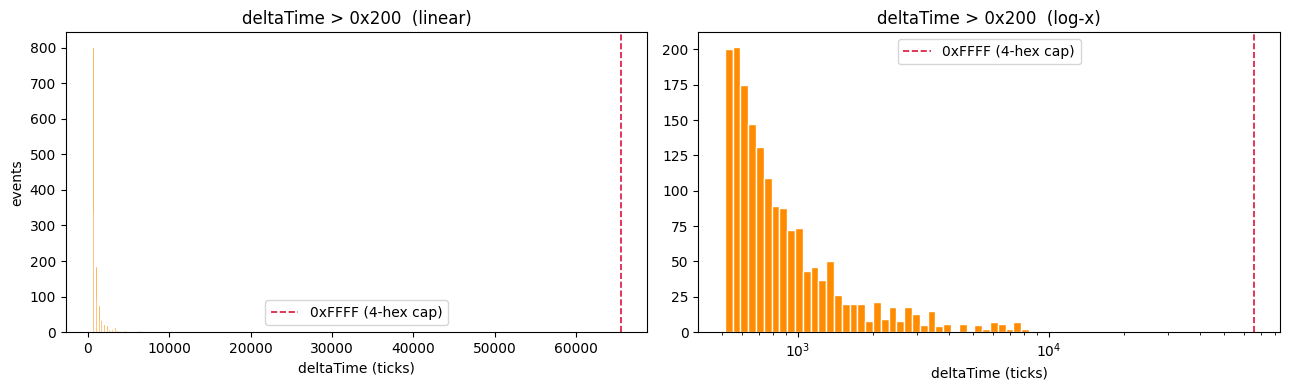

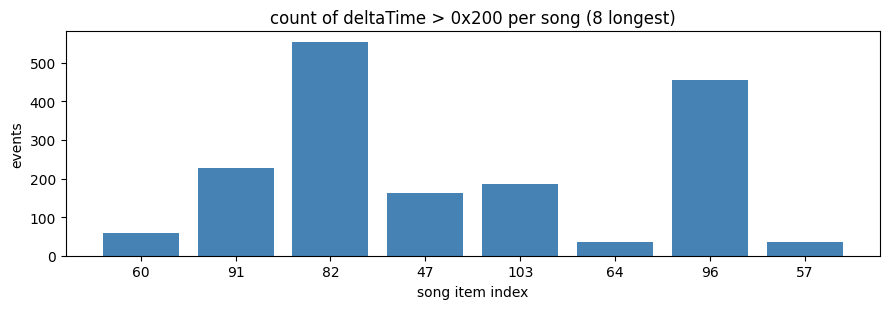

In [9]:
if len(big):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    # linear histogram
    axes[0].hist(big, bins=40, color='darkorange', edgecolor='white')
    axes[0].axvline(0xFFFF, color='crimson', ls='--', lw=1.2, label='0xFFFF (4-hex cap)')
    axes[0].set_title('deltaTime > 0x200  (linear)'); axes[0].set_xlabel('deltaTime (ticks)'); axes[0].set_ylabel('events'); axes[0].legend()
    # log-x histogram
    axes[1].hist(big, bins=np.logspace(np.log10(THRESH), np.log10(big.max()), 40), color='darkorange', edgecolor='white')
    axes[1].axvline(0xFFFF, color='crimson', ls='--', lw=1.2, label='0xFFFF (4-hex cap)')
    axes[1].set_xscale('log'); axes[1].set_title('deltaTime > 0x200  (log-x)'); axes[1].set_xlabel('deltaTime (ticks)'); axes[1].legend()
    plt.tight_layout(); plt.show()

    # per-song count of large deltas (which of the 8 longest contribute them)
    fig, ax = plt.subplots(figsize=(9, 3.2))
    order = list(per_song.keys())
    ax.bar([str(k) for k in order], [per_song[k] for k in order], color='steelblue')
    ax.set_title('count of deltaTime > 0x200 per song (8 longest)'); ax.set_xlabel('song item index'); ax.set_ylabel('events')
    plt.tight_layout(); plt.show()
else:
    print('no deltaTime > 0x200 found in the 8 longest songs')

## 7. Segment-length distribution (split at deltaTime ≥ 0x400)

Treat any FIELD event with deltaTime ≥ 0x400 as a **segment boundary** — a long inter-event
gap marks a natural break (analogous to NotaGen splitting the tunebody at barlines). Each
boundary event *starts* a new segment; we histogram the resulting per-segment event counts
across the 8 longest songs. This shows how a delta-based chunker would carve these songs.

In [10]:
SPLIT = 0x400

def segment_lengths(text):
    '''Event counts of each segment; a FIELD event with deltaTime >= SPLIT starts a new one.'''
    segs, cur = [], 0
    for line in text.split('\n'):
        head, _, rest = line.partition(' ')
        if head not in FIELD_SET:
            continue                       # skip header / non-field lines
        dt_tok = rest.split(' ', 1)[0] if rest else ''
        try:
            dt = int(dt_tok, 16)
        except ValueError:
            dt = 0
        if dt >= SPLIT and cur > 0:        # boundary: close current segment, open a new one
            segs.append(cur)
            cur = 0
        cur += 1
    if cur > 0:
        segs.append(cur)
    return segs

seg_lengths = []
per_song_nseg = {}
for idx in top8:
    text = tk.decode_patches(all_items[int(idx)]['patches'].long().tolist())
    segs = segment_lengths(text)
    seg_lengths += segs
    per_song_nseg[int(idx)] = len(segs)

seg = np.array(seg_lengths)
print('split threshold     : deltaTime >= 0x%X' % SPLIT)
print('total segments      :', len(seg))
print('segment length (events): min=%d  max=%d  mean=%.1f  median=%d' %
      (seg.min(), seg.max(), seg.mean(), int(np.median(seg))))
for q in (50, 90, 95, 99):
    print('  %dth percentile: %d events' % (q, int(np.percentile(seg, q))))
print('segments longer than patch_length window is N/A (segments are event-runs, not patches)')

split threshold     : deltaTime >= 0x400
total segments      : 461
segment length (events): min=1  max=19864  mean=690.2  median=20
  50th percentile: 20 events
  90th percentile: 1764 events
  95th percentile: 3004 events
  99th percentile: 11509 events
segments longer than patch_length window is N/A (segments are event-runs, not patches)


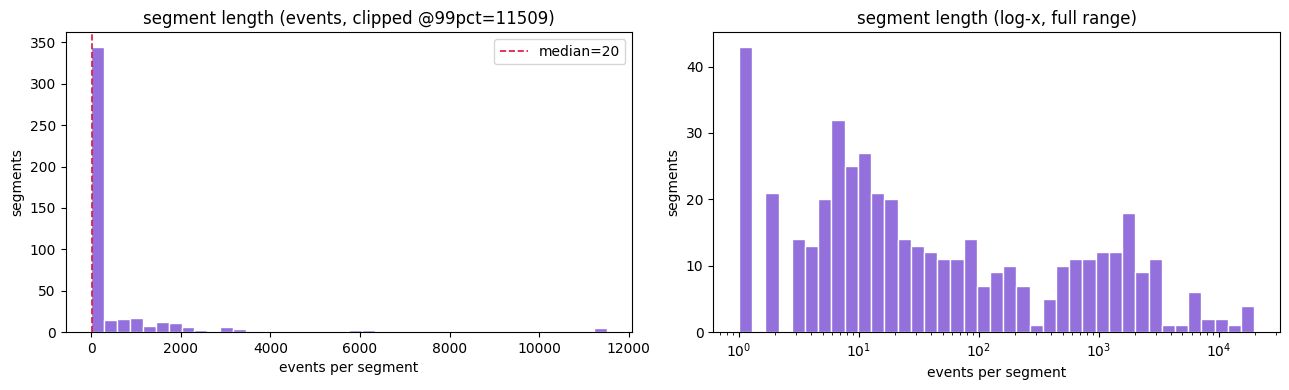

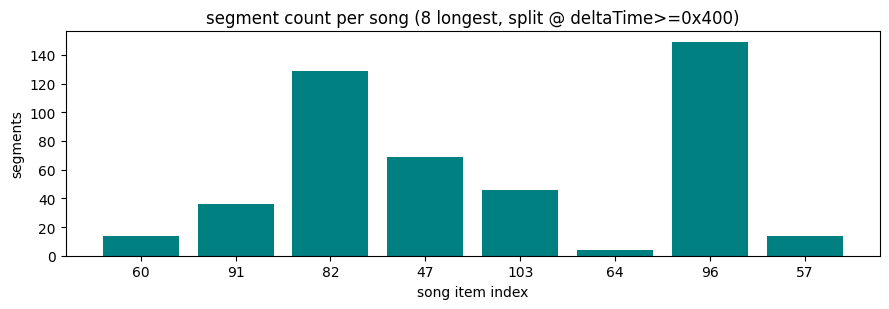

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# linear histogram, clipped at the 99th pct so the long tail doesn't flatten the bulk
clip = int(np.percentile(seg, 99))
axes[0].hist(np.clip(seg, None, clip), bins=40, color='mediumpurple', edgecolor='white')
axes[0].axvline(np.median(seg), color='crimson', ls='--', lw=1.2, label='median=%d' % int(np.median(seg)))
axes[0].set_title('segment length (events, clipped @99pct=%d)' % clip)
axes[0].set_xlabel('events per segment'); axes[0].set_ylabel('segments'); axes[0].legend()
# log-x histogram (full range)
axes[1].hist(seg, bins=np.logspace(0, np.log10(seg.max()), 40), color='mediumpurple', edgecolor='white')
axes[1].set_xscale('log'); axes[1].set_title('segment length (log-x, full range)')
axes[1].set_xlabel('events per segment'); axes[1].set_ylabel('segments')
plt.tight_layout(); plt.show()

# segments per song
fig, ax = plt.subplots(figsize=(9, 3.2))
order = list(per_song_nseg.keys())
ax.bar([str(k) for k in order], [per_song_nseg[k] for k in order], color='teal')
ax.set_title('segment count per song (8 longest, split @ deltaTime>=0x400)')
ax.set_xlabel('song item index'); ax.set_ylabel('segments')
plt.tight_layout(); plt.show()